In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score, recall_score, precision_score
from sklearn.dummy import DummyClassifier

import mlflow
import mlflow.sklearn
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
PROJECT_ROOT = Path.cwd().parent
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
MLFLOW_ARTIFACTS = PROJECT_ROOT / "mlruns"
MLFLOW_ARTIFACTS.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
LOG_MLFLOW = False

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
mlflow.set_experiment("churn_baseline")

print("tracking uri:", mlflow.get_tracking_uri())

tracking uri: sqlite:///c:/Users/mateu/OneDrive/FIAP - Pós/FASE1/TechChallenge/mlflow.db


# Tech Challenge — Fase 1
## Previsão de Churn em Telecom

### Problema de Negócio
Uma operadora de telecom deseja reduzir o churn (cancelamento de clientes).  
O objetivo é prever quais clientes têm maior probabilidade de sair, permitindo ações preventivas.  
Para esse exercício, parto da hipótese de que o não prever a saída de um cliente é mais custoso que agir sobre um clinete que não sairia.

### Objetivo do Notebook
- Preencher ML Canvas
- Entender os dados (EDA completa)
- Definir métricas
- Construir modelos baseline

## ML Canvas

### Problema
Prever churn de clientes.

### Stakeholders
- Diretoria
- Marketing
- CRM

### Decisão suportada
Quem deve receber ação de retenção

### Variável alvo
Churn Value (1 ou 0)

### Métrica de negócio
Redução de churn / preservação de receita / aumento do NPS

### Métrica técnica
Recall, AUC-ROC, F1-score

### Ação baseada no modelo
Contato proativo / oferta / melhora de qualidade do serviço



In [38]:
# Importação dos dados
df_raw = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

df_raw.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [39]:
print('O dataset possui ' + str(df_raw.shape[0]) + ' linhas e ' + str(df_raw.shape[1]) + ' colunas.')
df_raw.info()

O dataset possui 7043 linhas e 33 colunas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-n

In [40]:
df_raw.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


O dataset possui 7043 linhas e 33 colunas.

As variáveis incluem informações demográficas, serviços contratados e dados financeiros dos clientes.

A variável alvo é "Churn Value", indicando 1 se o cliente cancelou o serviço.

#### Qualidade dos Dados

Foram identificadas algumas colunas que não agregam valor ao modelo ou podem causar vazamento de informação:
- A coluna "Count" do dataset não possui variação.
- A coluna "CustomerID" serve apenas como identificador de cliente.
- Informações geográficas contidas nas colunas "Lat Long","Latitude" e "Longitude" tendem a não ter muita utilidade também. A menos que possuíssemos informações mais específicas de presença ou oferta de concorrentes nas diferentes regiões, o que de momento, não é o caso.
- A coluna "Churn Reason" só faz sentido após o churn, variável que estamos tentando prever.
- Churn Score: variável derivada (possível leakage).
- CLTV: pode conter informação futura.
- Churn Label: possui a mesma informação contida na "Churn Value", mas com strings.

Essas variáveis serão removidas para garantir integridade do modelo.

Além disso a coluna 'Total Charges" está como obj e precisa ser convertida para numérico.

In [41]:
df = df_raw.drop(columns=[
    "CustomerID",
    "Count",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Reason",
    "Churn Score",
    "CLTV",
    "Churn Label"
])

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [42]:
# Conferindo a existência de linhas nulas
df.isnull().sum()

Country               0
State                 0
City                  0
Zip Code              0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
dtype: int64

In [43]:
# Analisando as linhas que possuem nulos na coluna "Total Charges"
indices_contendo_nulos = df.loc[df['Total Charges'].isnull()].index.tolist()
df_raw.iloc[indices_contendo_nulos]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,,No,0,44,2342,NaN


In [44]:
df = df.dropna()

y = df["Churn Value"]
X = df.drop(columns=["Churn Value"])

df.to_csv("../data/processed/churn_clean.csv", index=False)
print(y.value_counts(normalize=True))

Churn Value
0    0.734215
1    0.265785
Name: proportion, dtype: float64


A variável alvo apresenta desbalanceamento moderado, com aproximadamente 26% de churn.

Isso indica a necessidade de métricas além da acurácia.

## Insights iniciais

- O dataset apresenta boa qualidade geral
- Algumas variáveis indicam potencial vazamento de informação
- O churn apresenta leve desbalanceamento
- Há forte presença de variáveis categóricas

In [45]:
cat_cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method'
]

for col in cat_cols:
    print(df.groupby(col)['Churn Value'].mean().sort_values(ascending=False))

Gender
Female    0.269595
Male      0.262046
Name: Churn Value, dtype: float64
Senior Citizen
Yes    0.416813
No     0.236503
Name: Churn Value, dtype: float64
Partner
No     0.329761
Yes    0.197171
Name: Churn Value, dtype: float64
Dependents
No     0.325758
Yes    0.065432
Name: Churn Value, dtype: float64
Phone Service
Yes    0.267475
No     0.250000
Name: Churn Value, dtype: float64
Multiple Lines
Yes                 0.286485
No                  0.250812
No phone service    0.250000
Name: Churn Value, dtype: float64
Internet Service
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: Churn Value, dtype: float64
Online Security
No                     0.417787
Yes                    0.146402
No internet service    0.074342
Name: Churn Value, dtype: float64
Online Backup
No                     0.399417
Yes                    0.215670
No internet service    0.074342
Name: Churn Value, dtype: float64
Device Protection
No                     0.391403
Yes       

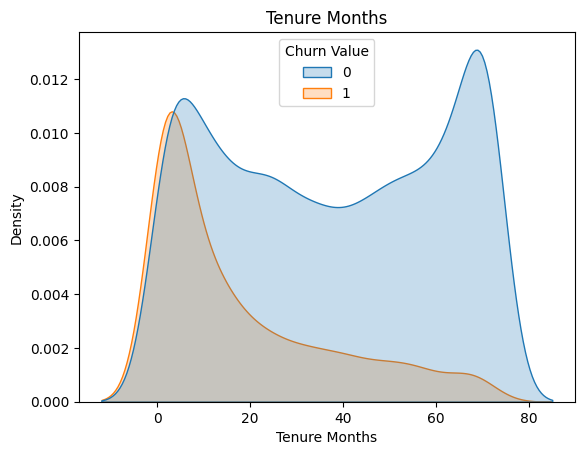

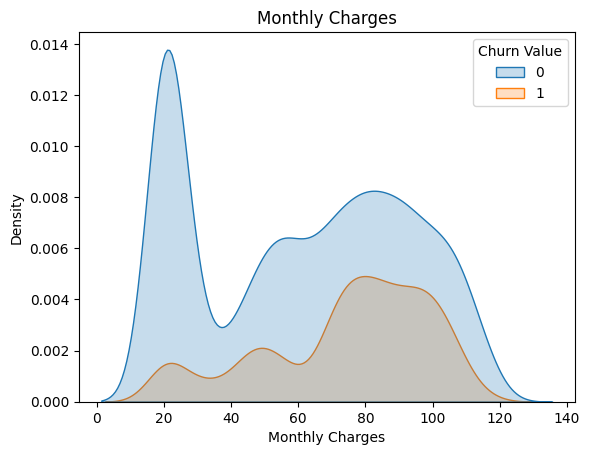

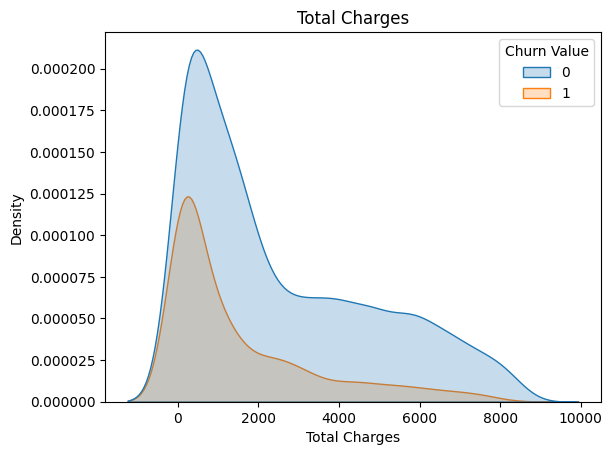

In [46]:

num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

for col in num_cols:
    sns.kdeplot(data=df, x=col, hue='Churn Value', fill=True)
    plt.title(col)
    plt.show()

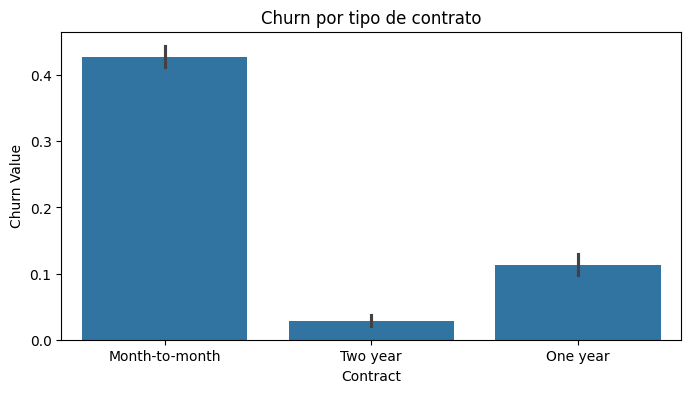

In [47]:
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='Contract', y='Churn Value')
plt.title("Churn por tipo de contrato")
plt.show()

In [48]:
df.groupby(['Contract', 'Tech Support'])['Churn Value'].mean().unstack()

Tech Support,No,No internet service,Yes
Contract,,,
Month-to-month,0.503731,0.188931,0.307004
One year,0.147217,0.024793,0.135870
Two year,0.059574,0.007899,0.035496


<Axes: >

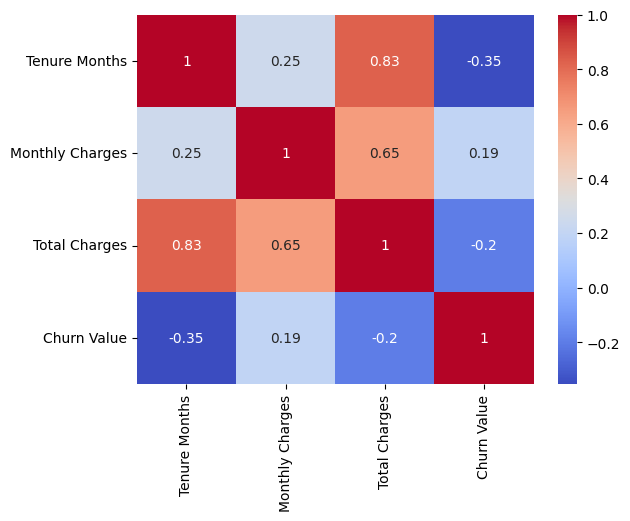

In [49]:
df['Churn Value'] = df['Churn Value'].astype(int)

corr = df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

A análise exploratória mostrou que o churn está fortemente associado ao estágio inicial do ciclo de vida do cliente (tenure baixo), à ausência de serviços de suporte e a contratos mais flexíveis.

Além disso, clientes com maior custo mensal apresentam maior propensão ao cancelamento, indicando possível sensibilidade a preço.

Esses padrões sugerem que churn não é aleatório, mas sim concentrado em segmentos específicos, o que reforça a capacidade do modelo em capturar esses comportamentos.

### Preparação Baseline


In [50]:
drop_cols = ['Country', 'State', 'City', 'Zip Code']

X = df.drop(['Churn Value'] + drop_cols, axis=1)
y = df['Churn Value']

In [51]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,  
    random_state=42
)

In [52]:

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

### Modelo Baseline


In [53]:

pipe_dummy = Pipeline([
    ('prep', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42))
])

pipe_dummy.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [54]:

pipe_log = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipe_log.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [55]:

pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

pipe_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

### Avaliação

In [56]:

def avaliar_modelo(model, X_test, y_test, nome):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {nome} =====")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_proba)
    print(f"AUC-ROC: {auc:.4f}")


avaliar_modelo(pipe_dummy, X_test, y_test, "Dummy Classifier")
avaliar_modelo(pipe_log, X_test, y_test, "Logistic Regression")
avaliar_modelo(pipe_rf, X_test, y_test, "Random Forest")


===== Dummy Classifier =====
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1033
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407

AUC-ROC: 0.5000

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407

AUC-ROC: 0.8431

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   mac

c:\Users\mateu\OneDrive\FIAP - Pós\FASE1\TechChallenge\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mateu\OneDrive\FIAP - Pós\FASE1\TechChallenge\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mateu\OneDrive\FIAP - Pós\FASE1\TechChallenge\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [57]:

mlflow.set_experiment("churn_baseline")

models = {
    "dummy": pipe_dummy,
    "logistic_regression": pipe_log,
    "random_forest": pipe_rf
}

if LOG_MLFLOW:
    for name, model in models.items():
        with mlflow.start_run(run_name=name):
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]

            mlflow.log_param("model_name", name)
            mlflow.log_param("test_size", 0.2)
            mlflow.log_param("stratify", True)
            mlflow.log_param("random_state", 42)

            mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
            mlflow.log_metric("precision_churn", precision_score(y_test, y_pred))
            mlflow.log_metric("recall_churn", recall_score(y_test, y_pred))
            mlflow.log_metric("f1_churn", f1_score(y_test, y_pred))
            mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))

            mlflow.sklearn.log_model(model, name)

In [58]:
y_proba = pipe_log.predict_proba(X_test)[:, 1]

for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred = (y_proba >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.70      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1033
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79   

#### Conclusão do baseline

A Regressão Logística apresentou melhor desempenho em relação ao Random Forest, especialmente na métrica de recall da classe churn, que é crítica para o problema de negócio.

Apesar de sua simplicidade, o modelo foi capaz de capturar os principais padrões identificados na análise exploratória.  

No entanto, o recall obtido ainda indica que uma parcela significativa de clientes propensos ao churn não está sendo identificada, o que motiva ajustes adicionais no modelo, como a calibração do threshold de decisão.

A redução do threshold de decisão permitiu aumentar significativamente o recall da classe churn, reduzindo o número de falsos negativos, que representam clientes perdidos.

No entanto, essa melhoria ocorre ao custo de uma redução na precisão, implicando maior número de ações desnecessárias.

Considerando o contexto do problema, podemos pensar como uma decisão de alocação de recursos de retenção, onde, para cada cliente, a empresa pode optar por realizar uma ação de marketing com custo associado.

O custo de um falso positivo foi definido como o custo da ação de retenção aplicada a um cliente que não churnaria.

Já o custo de um falso negativo foi definido como a perda de receita associada ao churn de um cliente que poderia ter sido retido, estimada como a receita mensal multiplicada por um horizonte de retenção esperado após a intervenção.

Assim, o custo foi utilizado como ferramenta auxiliar para orientar a escolha do threshold de decisão, garantindo um equilíbrio entre a identificação de clientes em risco (recall) e o custo operacional das ações.

Para esse exercício, simulei 3 meses como horizonte de retenção após a ação e um custo fixo de ação de 100.


In [59]:

# -------------------------
# PARÂMETROS DE NEGÓCIO
# -------------------------

# Receita média de clientes que churnaram
ticket_medio_churn = df.loc[df['Churn Value'] == 1, 'Monthly Charges'].mean()

# Hipótese: retenção por X meses
meses_retencao = 3

# Custos
custo_fn = ticket_medio_churn * meses_retencao
custo_fp = 100  # custo da campanha (nesse caso fictício, a equipe comercial/markleting deveria ser consultada)

# -------------------------
# TESTE DE THRESHOLDS
# -------------------------

thresholds = np.arange(0.1, 0.9, 0.05)

resultados = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    tn = ((y_pred == 0) & (y_test == 0)).sum()
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    custo_total = fp * custo_fp + fn * custo_fn
    
    # valor "salvo" (clientes que você acertou agir)
    valor_retido = tp * custo_fn
    
    # valor líquido aproximado
    valor_liquido = valor_retido - (fp * custo_fp)
    
    resultados.append({
        'threshold': t,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'tn': tn,
        'recall': tp / (tp + fn),
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'f1_score': f1,
        'accuracy': accuracy,
        'custo_total': custo_total,
        'valor_liquido': valor_liquido
    })

df_resultados = pd.DataFrame(resultados)

# Ordenar por melhor valor (ou menor custo)
df_resultados.sort_values(by='valor_liquido', ascending=False).head(10)

,threshold,fp,fn,tp,tn,recall,precision,f1_score,accuracy,custo_total,valor_liquido
7,0.45,153,129,245,880,0.655080,0.615578,0.634715,0.799574,44108.795586,39414.379213
6,0.40,189,114,260,844,0.695187,0.579065,0.631835,0.784648,44358.935634,39164.239165
5,0.35,227,102,272,806,0.727273,0.545090,0.623139,0.766169,45479.047673,38044.127127
8,0.50,126,149,225,907,0.601604,0.641026,0.620690,0.804549,45875.275522,37647.899278
4,0.30,262,92,282,771,0.754011,0.518382,0.614379,0.748401,46745.807705,36777.367095
3,0.25,310,75,299,723,0.799465,0.490969,0.608342,0.726368,47749.299759,35773.875040
2,0.20,372,49,325,661,0.868984,0.466284,0.606909,0.700782,48142.875843,35380.298957
9,0.55,106,174,200,927,0.534759,0.653595,0.588235,0.800995,49458.375441,34064.799358
1,0.15,428,43,331,605,0.885027,0.436100,0.584289,0.665245,52402.931862,31120.242937
10,0.60,78,204,170,955,0.454545,0.685484,0.546624,0.799574,53358.095345,30165.079454


In [60]:
if LOG_MLFLOW:
    with mlflow.start_run(run_name="logistic_regression_threshold_045"):
        threshold = 0.45
        y_pred_045 = (pipe_log.predict_proba(X_test)[:, 1] >= threshold).astype(int)

        mlflow.log_param("model_name", "logistic_regression")
        mlflow.log_param("threshold", threshold)
        mlflow.log_param("custo_fp", custo_fp)
        mlflow.log_param("meses_retencao", meses_retencao)
        mlflow.log_param("custo_fn", custo_fn)

        mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_045))
        mlflow.log_metric("precision_churn", precision_score(y_test, y_pred_045))
        mlflow.log_metric("recall_churn", recall_score(y_test, y_pred_045))
        mlflow.log_metric("f1_churn", f1_score(y_test, y_pred_045))

A análise conjunta das métricas técnicas e da simulação de valor econômico indicou que o threshold de 0.45 apresenta o melhor equilíbrio entre performance preditiva e eficiência operacional.

Nesse ponto, o modelo mantém níveis consistentes de recall e precisão, ao mesmo tempo em que maximiza o valor líquido das ações de retenção.

Observa-se que thresholds mais baixos, embora aumentem o recall, levam a um crescimento significativo de falsos positivos, elevando o custo das intervenções e reduzindo o retorno econômico.

Por outro lado, thresholds mais altos reduzem o número de ações, mas aumentam a perda de clientes relevantes.

Dessa forma, o threshold selecionado reflete uma estratégia mais eficiente de alocação de recursos, priorizando clientes com maior probabilidade de churn sem incorrer em custos excessivos.